# 01. Exploratory data analysis

Understand the *Students Performance* dataset before modelling: distributions, background effects, statistical significance and the class balance of the targets we will predict.

All logic lives in the `edupulse` package. This notebook only calls it, so the results here are the same ones the CLI, API and dashboard use.

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Image, Markdown, display
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)

from edupulse.config import get_settings
S = get_settings()
print("EduPulse project root:", S.project_root)

EduPulse project root: C:\Users\WzA\Desktop\ZAIN\PAI


## 1. Load, clean and validate
The loader normalises column names, strips whitespace, drops duplicates and validates every column against a declared schema (allowed categories, score ranges).

In [2]:
from edupulse.data import load_clean
raw = load_clean()
raw.head()

11:37:40 | INFO     | edupulse.data.loader | Loaded raw dataset StudentsPerformance.csv with shape (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental_level_of_education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_preparation_course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math_score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading_score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing_score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


## 2. Feature engineering
`engineer_features` adds totals, averages, pass flags, the ordinal parental-education rank and the two targets: `performance_level` (low/medium/high) and `at_risk` (average < 60).

In [4]:
from edupulse.features import engineer_features
df = engineer_features(raw)
print(df.shape)
df[['average_score','performance_level','at_risk','n_passed','parental_education_rank']].head(10)

(1000, 22)


,average_score,performance_level,at_risk,n_passed,parental_education_rank
0,72.67,medium,0,3,4
1,82.33,high,0,3,2
2,92.67,high,0,3,5
3,49.33,low,1,3,3
4,76.33,medium,0,3,2
5,77.33,medium,0,3,3
6,91.67,high,0,3,2
7,40.67,low,1,2,2
8,65.00,medium,0,3,1
9,49.33,low,1,2,1


In [5]:
print('At-risk rate: {:.1%}'.format(df.at_risk.mean()))
df.performance_level.value_counts(normalize=True).round(3)

At-risk rate: 28.5%


performance_level
medium    0.517
low       0.285
high      0.198
Name: proportion, dtype: float64

## 3. Score distributions and correlations

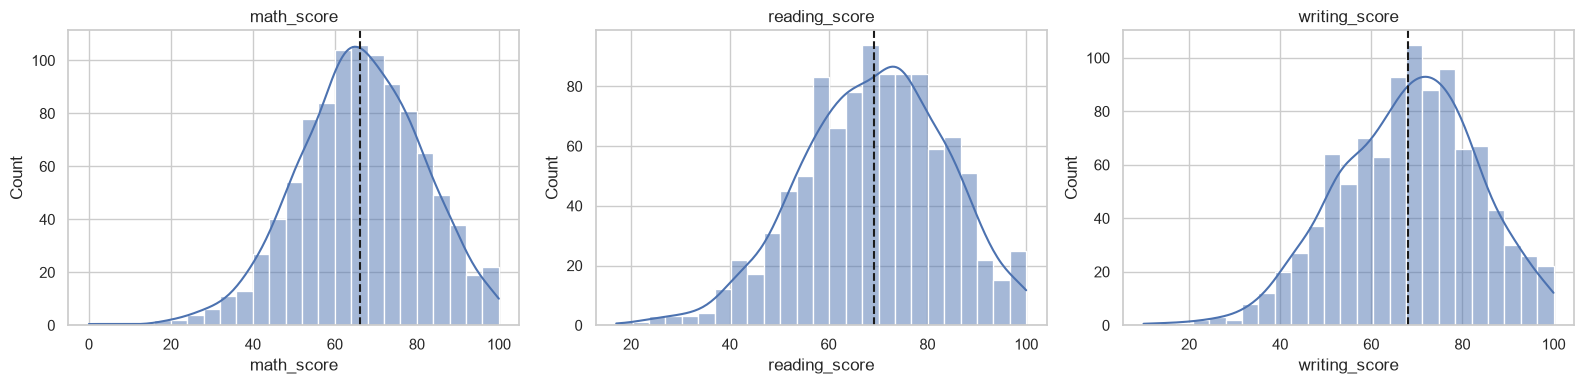

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ['math_score','reading_score','writing_score']):
    sns.histplot(df[c], kde=True, bins=25, ax=ax); ax.axvline(df[c].mean(), ls='--', c='k'); ax.set_title(c)
plt.tight_layout()

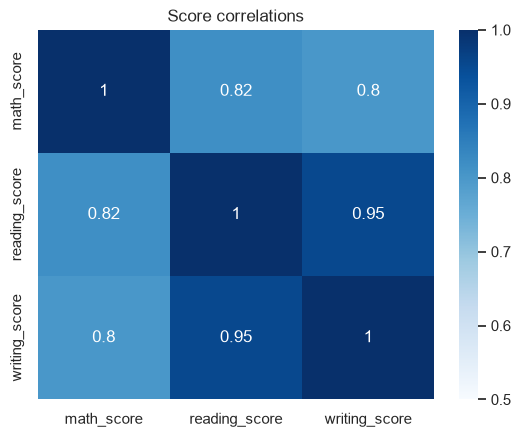

In [7]:
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True, cmap='Blues', vmin=.5); plt.title('Score correlations');

Reading and writing are almost interchangeable (r of about 0.95). Math is related but distinct (r of about 0.8), which is why predicting math from reading and writing is a meaningful regression task.

## 4. Which background factors matter?
Welch t-tests or one-way ANOVA on the average score, with eta squared as the effect size.

In [8]:
from edupulse.eda import profile
prof = profile(df)
pd.DataFrame(prof['tests']).T.sort_values('eta_squared', ascending=False).style.format({'p_value':'{:.2e}','statistic':'{:.2f}','eta_squared':'{:.3f}'})

,test,statistic,p_value,eta_squared
lunch,welch_t,-9.32,1.58e-19,0.084
test_preparation_course,welch_t,8.59,4.42e-17,0.066
parental_level_of_education,anova_f,10.75,4.38e-10,0.051
race_ethnicity,anova_f,9.10,3.23e-07,0.035
gender,welch_t,4.18,3.18e-05,0.017


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.flat, ['lunch','test_preparation_course','parental_level_of_education','race_ethnicity','gender']):
    order = df.groupby(c)['average_score'].median().sort_values().index
    sns.boxplot(data=df, x=c, y='average_score', order=order, ax=ax, hue=c, legend=False, palette='crest'); ax.tick_params(axis='x', rotation=25); ax.set_xlabel('')
axes.flat[-1].axis('off'); plt.tight_layout()

## 5. At-risk rate by background
This is the only signal the early-warning model gets. Scores are not allowed as inputs.

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, c in zip(axes, ['lunch','test_preparation_course','parental_level_of_education','race_ethnicity','gender']):
    df.groupby(c)['at_risk'].mean().sort_values().plot.barh(ax=ax, color='#EF4444'); ax.axvline(df.at_risk.mean(), ls='--', c='k'); ax.set_title(c); ax.set_ylabel('')
plt.tight_layout()

## Takeaways
* Lunch type (a proxy for household income) and test preparation have the largest effects on scores. Ethnicity and parental education come next. Gender mainly changes which subject is stronger.
* About 28.5% of students average below 60, so the binary target is moderately imbalanced.
* Reading and writing correlate far more with each other than with math, so math is the natural regression target.